# CO1 - AT3 - Exploratory Data Analysis - Based Practical Assessment

**Name:** Jithendra Kumar Reddy  
**Register Number:** 192472180  
**Course:** Fundamentals of Data Science  
**Course Code:** DSA04  
**Assessment Tool:** Unit 1 - Assessment Tool 3

This notebook performs Exploratory Data Analysis on the five datasets provided in the assessment: Education Analytics, Healthcare Analytics, Retail Sales, Banking Loan Approval, and Agriculture Crop Yield.

## Common EDA Workflow

For every dataset, the notebook checks:
1. Number of rows and columns
2. Data types
3. Missing values and duplicates
4. Mean, median, minimum, maximum and standard deviation
5. Categorical distributions
6. Bar chart, histogram, scatter plot and box plot
7. Correlations and important patterns
8. Key observations and conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 4.5)

def eda_profile(df, name, numeric_cols):
    print(name)
    print("Shape:", df.shape)
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values:")
    print(df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nDescriptive statistics:")
    print(df[numeric_cols].agg(['mean','median','min','max','std']).T.round(2))

    print("\nIQR outlier counts:")
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        low = q1 - 1.5 * iqr
        high = q3 + 1.5 * iqr
        count = ((df[col] < low) | (df[col] > high)).sum()
        print(col, ":", int(count))


## Education Analytics Dataset

**Purpose & Significance:** A college wants to understand how attendance, study hours and internal marks are associated with student results so that academic support can be targeted early.

In [2]:
edu = pd.DataFrame({
'Student_ID':[f'S{i:02d}' for i in range(1,21)],
'Attendance':[92,55,78,60,88,47,95,72,50,83,66,90,58,76,62,85,45,80,68,53],
'Study_Hours':[5,2,4,3,5,1,6,3,2,4,3,5,2,4,3,5,1,4,3,2],
'Internal_Marks':[45,24,38,28,42,20,48,35,22,40,30,44,25,36,29,41,18,39,32,23],
'Result':['Pass','Fail','Pass','Fail','Pass','Fail','Pass','Pass','Fail','Pass','Fail','Pass','Fail','Pass','Fail','Pass','Fail','Pass','Pass','Fail']})
eda_profile(edu, 'Education Analytics Dataset', ['Attendance','Study_Hours','Internal_Marks'])


Education Analytics Dataset
Shape: (20, 5)

Data types:
Student_ID        object
Attendance         int64
Study_Hours        int64
Internal_Marks     int64
Result            object
dtype: object

Missing values:
Student_ID        0
Attendance        0
Study_Hours       0
Internal_Marks    0
Result            0
dtype: int64

Duplicate rows: 0

Descriptive statistics:
                 mean  median   min   max    std
Attendance      70.15    70.0  45.0  95.0  15.94
Study_Hours      3.35     3.0   1.0   6.0   1.42
Internal_Marks  32.95    33.5  18.0  48.0   9.09

IQR outlier counts:
Attendance : 0
Study_Hours : 0
Internal_Marks : 0


In [3]:
print(edu['Result'].value_counts())
print((edu['Result'].value_counts(normalize=True)*100).round(2))


Result
Pass    11
Fail     9
Name: count, dtype: int64
Result
Pass    55.0
Fail    45.0
Name: proportion, dtype: float64


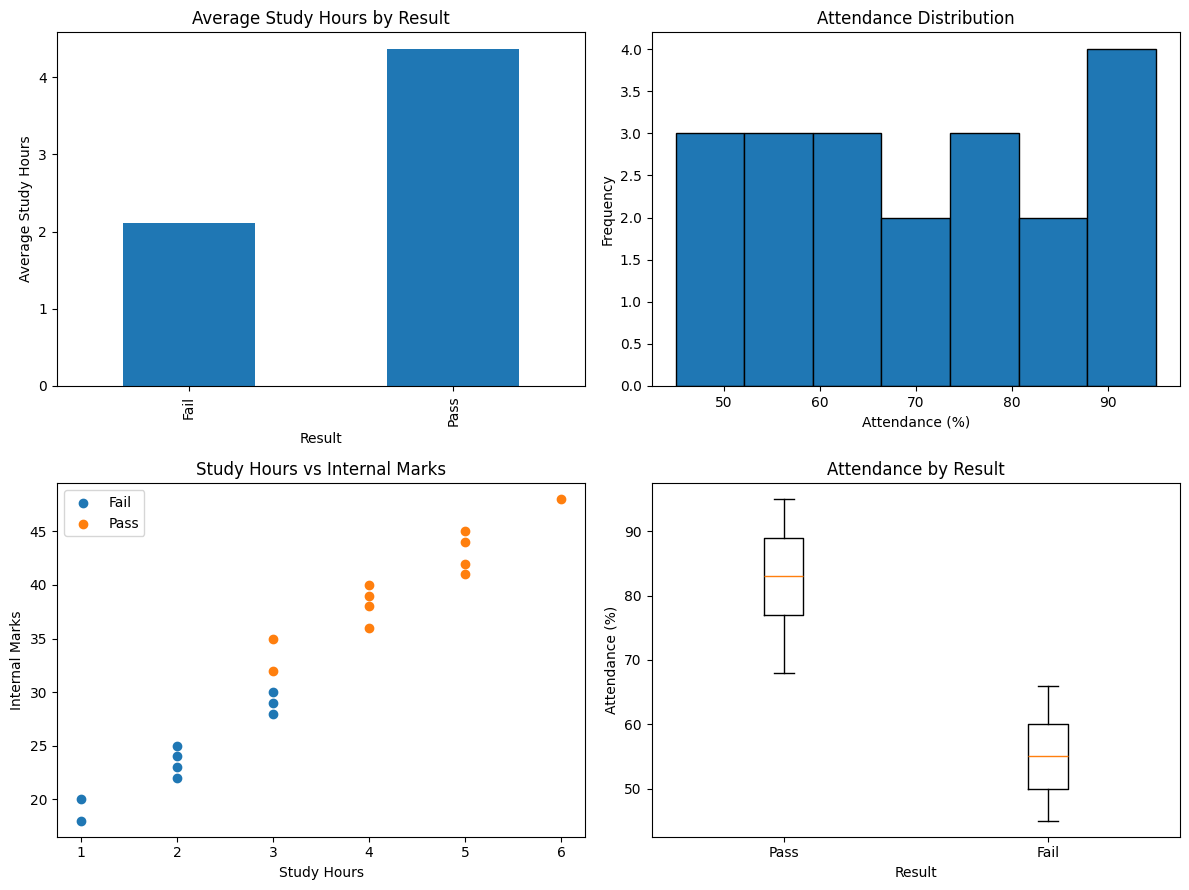

In [4]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
edu.groupby('Result')['Study_Hours'].mean().plot(kind='bar', ax=axes[0,0], title='Average Study Hours by Result')
axes[0,0].set_xlabel('Result'); axes[0,0].set_ylabel('Average Study Hours')
axes[0,1].hist(edu['Attendance'], bins=7, edgecolor='black'); axes[0,1].set_title('Attendance Distribution'); axes[0,1].set_xlabel('Attendance (%)'); axes[0,1].set_ylabel('Frequency')
for value, sub in edu.groupby('Result'): axes[1,0].scatter(sub['Study_Hours'], sub['Internal_Marks'], label=value)
axes[1,0].set_title('Study Hours vs Internal Marks'); axes[1,0].set_xlabel('Study Hours'); axes[1,0].set_ylabel('Internal Marks'); axes[1,0].legend()
axes[1,1].boxplot([edu.loc[edu.Result=='Pass','Attendance'], edu.loc[edu.Result=='Fail','Attendance']], tick_labels=['Pass','Fail'])
axes[1,1].set_title('Attendance by Result'); axes[1,1].set_xlabel('Result'); axes[1,1].set_ylabel('Attendance (%)')
plt.tight_layout(); plt.show()


                Attendance  Study_Hours  Internal_Marks
Attendance           1.000        0.976           0.998
Study_Hours          0.976        1.000           0.977
Internal_Marks       0.998        0.977           1.000


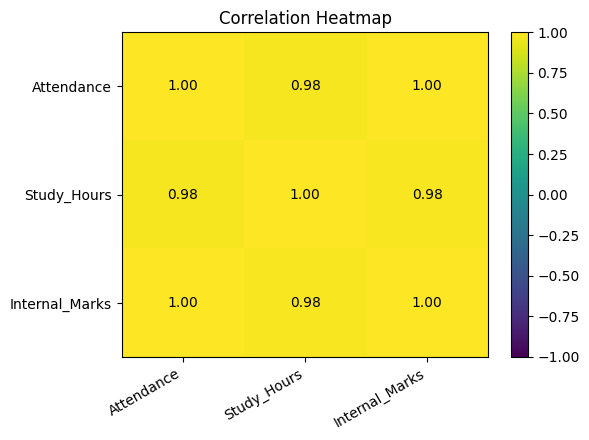

In [5]:
numeric_cols = edu.select_dtypes(include='number').columns
corr = edu[list(numeric_cols)].corr()
print(corr.round(3))
plt.figure(figsize=(6,4.5))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for r in range(len(corr)):
    for c in range(len(corr)):
        plt.text(c, r, f"{corr.iloc[r,c]:.2f}", ha='center', va='center')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Key Findings and Insights

1. Passing students have higher average attendance, study hours and internal marks than failing students.
2. Attendance and internal marks have a very strong positive relationship.
3. Study hours increase as student performance improves.
4. Most failing students have attendance below about 66%, while passing students are concentrated at higher attendance levels.
5. The dataset contains no missing values, duplicate rows or IQR outliers.

### Conclusion

The analysis suggests that attendance, study hours and internal marks are important observable factors associated with student results. Students below the lower attendance range should receive early academic support.

## Healthcare Analytics Dataset

**Purpose & Significance:** A hospital wants to identify important patterns in age, blood sugar, blood pressure and BMI that are associated with disease status.

In [6]:
health = pd.DataFrame({
'Patient_ID':[f'P{i:02d}' for i in range(1,21)],
'Age':[45,32,55,28,60,40,52,35,48,30,62,38,50,27,58,42,46,34,53,29],
'Sugar_Level':[145,98,180,90,200,120,165,105,155,95,210,115,170,88,190,130,150,100,175,92],
'BP':[130,118,145,110,150,125,140,120,135,115,155,122,142,108,148,128,132,116,144,112],
'BMI':[28,23,31,22,34,26,30,24,29,23,35,25,30,21,33,27,28,24,31,22],
'Disease_Status':['Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No','Yes','No']})
eda_profile(health, 'Healthcare Analytics Dataset', ['Age','Sugar_Level','BP','BMI'])


Healthcare Analytics Dataset
Shape: (20, 6)

Data types:
Patient_ID        object
Age                int64
Sugar_Level        int64
BP                 int64
BMI                int64
Disease_Status    object
dtype: object

Missing values:
Patient_ID        0
Age               0
Sugar_Level       0
BP                0
BMI               0
Disease_Status    0
dtype: int64

Duplicate rows: 0

Descriptive statistics:
               mean  median    min    max    std
Age           43.20    43.5   27.0   62.0  11.32
Sugar_Level  138.65   137.5   88.0  210.0  40.33
BP           129.75   129.0  108.0  155.0  14.52
BMI           27.30    27.5   21.0   35.0   4.26

IQR outlier counts:
Age : 0
Sugar_Level : 0
BP : 0
BMI : 0


In [7]:
print(health['Disease_Status'].value_counts())
print((health['Disease_Status'].value_counts(normalize=True)*100).round(2))


Disease_Status
Yes    10
No     10
Name: count, dtype: int64
Disease_Status
Yes    50.0
No     50.0
Name: proportion, dtype: float64


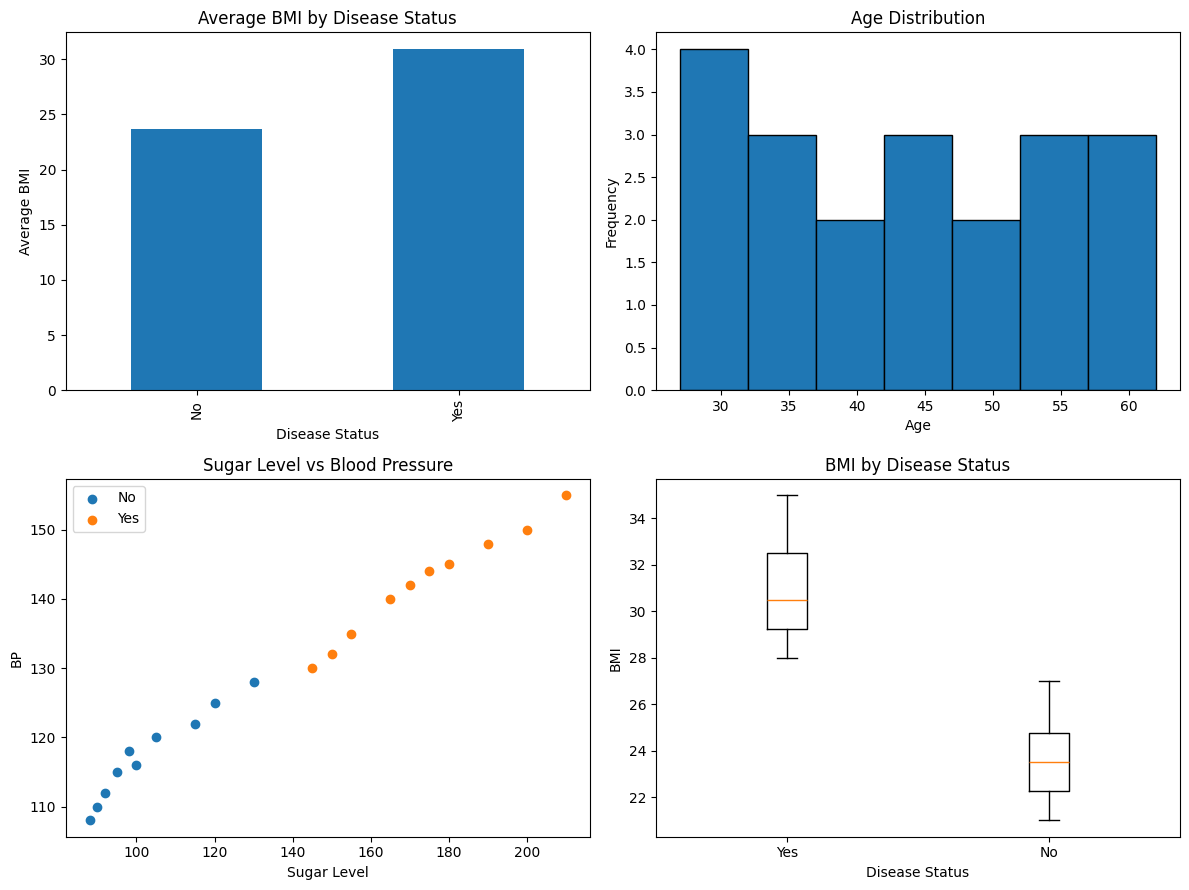

In [8]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
health.groupby('Disease_Status')['BMI'].mean().plot(kind='bar', ax=axes[0,0], title='Average BMI by Disease Status')
axes[0,0].set_xlabel('Disease Status'); axes[0,0].set_ylabel('Average BMI')
axes[0,1].hist(health['Age'], bins=7, edgecolor='black'); axes[0,1].set_title('Age Distribution'); axes[0,1].set_xlabel('Age'); axes[0,1].set_ylabel('Frequency')
for value, sub in health.groupby('Disease_Status'): axes[1,0].scatter(sub['Sugar_Level'], sub['BP'], label=value)
axes[1,0].set_title('Sugar Level vs Blood Pressure'); axes[1,0].set_xlabel('Sugar Level'); axes[1,0].set_ylabel('BP'); axes[1,0].legend()
axes[1,1].boxplot([health.loc[health.Disease_Status=='Yes','BMI'], health.loc[health.Disease_Status=='No','BMI']], tick_labels=['Yes','No'])
axes[1,1].set_title('BMI by Disease Status'); axes[1,1].set_xlabel('Disease Status'); axes[1,1].set_ylabel('BMI')
plt.tight_layout(); plt.show()


               Age  Sugar_Level     BP    BMI
Age          1.000        0.994  0.994  0.996
Sugar_Level  0.994        1.000  0.993  0.994
BP           0.994        0.993  1.000  0.993
BMI          0.996        0.994  0.993  1.000


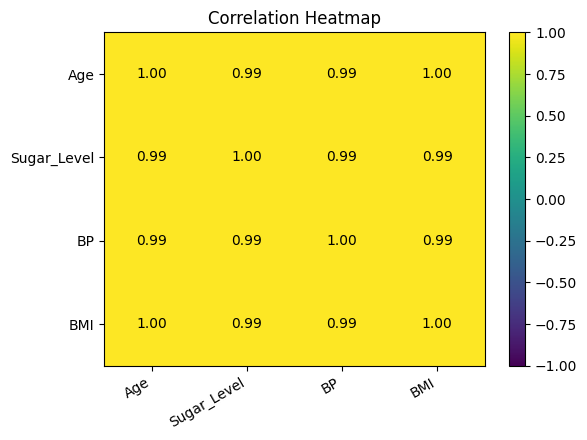

In [9]:
numeric_cols = health.select_dtypes(include='number').columns
corr = health[list(numeric_cols)].corr()
print(corr.round(3))
plt.figure(figsize=(6,4.5))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for r in range(len(corr)):
    for c in range(len(corr)):
        plt.text(c, r, f"{corr.iloc[r,c]:.2f}", ha='center', va='center')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Key Findings and Insights

1. Disease-positive patients consistently have higher age, sugar level, blood pressure and BMI than disease-negative patients.
2. BMI provides a clear visual separation between the two disease-status groups.
3. Sugar level and blood pressure increase together strongly in this sample.
4. The dataset is balanced with 10 disease-positive and 10 disease-negative patients.
5. No missing values, duplicate rows or IQR outliers were found.

### Conclusion

The analysis shows a clear association between higher BMI, sugar level, blood pressure, age and disease status. These variables can help prioritize patients for further screening, but the small sample should not be treated as a clinical diagnostic rule.

## Retail Sales Dataset

**Purpose & Significance:** A supermarket wants to identify high-selling categories, pricing patterns, discount effects and revenue patterns for better stocking and promotion decisions.

In [10]:
retail = pd.DataFrame({
'Product_ID':[f'PR{i:02d}' for i in range(1,21)],
'Category':['Grocery','Snacks','Dairy','Fruits','Vegetables','Grocery','Snacks','Dairy','Fruits','Vegetables','Grocery','Snacks','Dairy','Fruits','Vegetables','Grocery','Snacks','Dairy','Fruits','Vegetables'],
'Price':[50,30,45,60,40,80,25,55,70,35,90,20,65,75,45,100,35,50,80,30],
'Quantity_Sold':[20,35,18,25,30,15,40,16,22,28,12,45,14,20,26,10,32,19,18,35],
'Discount':[5,3,2,5,4,6,3,2,5,4,6,2,3,5,4,7,3,2,6,3],
'Revenue':[1000,1050,810,1500,1200,1200,1000,880,1540,980,1080,900,910,1500,1170,1000,1120,950,1440,1050]})
eda_profile(retail, 'Retail Sales Dataset', ['Price','Quantity_Sold','Discount','Revenue'])


Retail Sales Dataset
Shape: (20, 6)

Data types:
Product_ID       object
Category         object
Price             int64
Quantity_Sold     int64
Discount          int64
Revenue           int64
dtype: object

Missing values:
Product_ID       0
Category         0
Price            0
Quantity_Sold    0
Discount         0
Revenue          0
dtype: int64

Duplicate rows: 0

Descriptive statistics:
                 mean  median    min     max     std
Price            54.0    50.0   20.0   100.0   22.80
Quantity_Sold    24.0    21.0   10.0    45.0    9.67
Discount          4.0     4.0    2.0     7.0    1.56
Revenue        1114.0  1050.0  810.0  1540.0  221.42

IQR outlier counts:
Price : 0
Quantity_Sold : 0
Discount : 0
Revenue : 0


In [11]:
print(retail['Category'].value_counts())
print((retail['Category'].value_counts(normalize=True)*100).round(2))


Category
Grocery       4
Snacks        4
Dairy         4
Fruits        4
Vegetables    4
Name: count, dtype: int64
Category
Grocery       20.0
Snacks        20.0
Dairy         20.0
Fruits        20.0
Vegetables    20.0
Name: proportion, dtype: float64


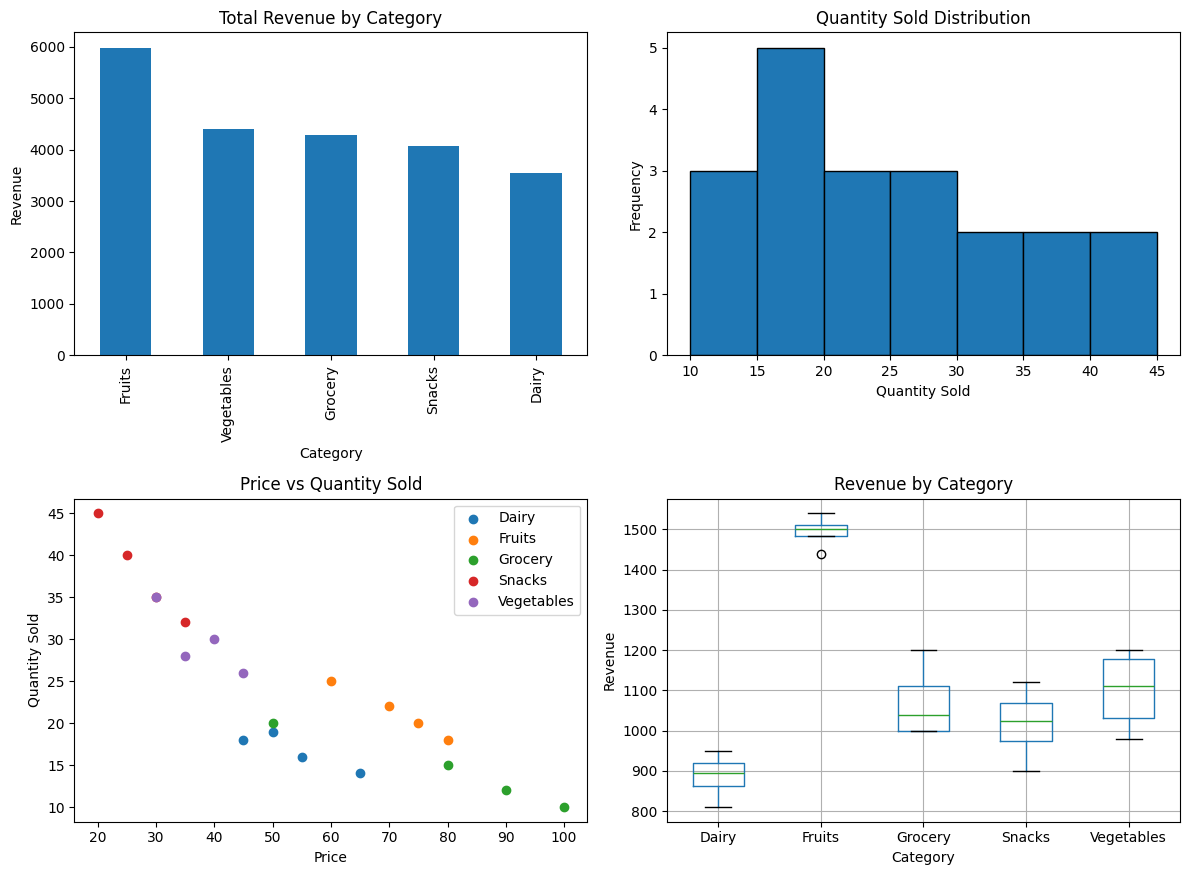

In [12]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
retail.groupby('Category')['Revenue'].sum().sort_values(ascending=False).plot(kind='bar', ax=axes[0,0], title='Total Revenue by Category')
axes[0,0].set_xlabel('Category'); axes[0,0].set_ylabel('Revenue')
axes[0,1].hist(retail['Quantity_Sold'], bins=7, edgecolor='black'); axes[0,1].set_title('Quantity Sold Distribution'); axes[0,1].set_xlabel('Quantity Sold'); axes[0,1].set_ylabel('Frequency')
for value, sub in retail.groupby('Category'): axes[1,0].scatter(sub['Price'], sub['Quantity_Sold'], label=value)
axes[1,0].set_title('Price vs Quantity Sold'); axes[1,0].set_xlabel('Price'); axes[1,0].set_ylabel('Quantity Sold'); axes[1,0].legend()
retail.boxplot(column='Revenue', by='Category', ax=axes[1,1]); axes[1,1].set_title('Revenue by Category'); axes[1,1].set_xlabel('Category'); axes[1,1].set_ylabel('Revenue'); plt.suptitle('')
plt.tight_layout(); plt.show()


               Price  Quantity_Sold  Discount  Revenue
Price          1.000         -0.868     0.786    0.388
Quantity_Sold -0.868          1.000    -0.507   -0.081
Discount       0.786         -0.507     1.000    0.576
Revenue        0.388         -0.081     0.576    1.000


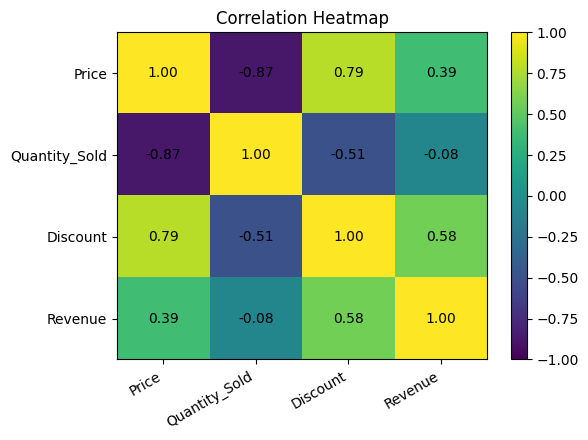

In [13]:
numeric_cols = retail.select_dtypes(include='number').columns
corr = retail[list(numeric_cols)].corr()
print(corr.round(3))
plt.figure(figsize=(6,4.5))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for r in range(len(corr)):
    for c in range(len(corr)):
        plt.text(c, r, f"{corr.iloc[r,c]:.2f}", ha='center', va='center')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Key Findings and Insights

1. Fruits generate the highest total revenue among the five categories.
2. Price and quantity sold have a strong negative relationship, indicating that lower-priced products tend to sell in larger quantities.
3. Snacks have the highest quantity sold in several records but do not produce the highest revenue.
4. Revenue varies by category even though each category has four products.
5. No missing values, duplicate rows or IQR outliers were found.

### Conclusion

The analysis shows that revenue depends on both price and sales volume. Fruits are the strongest revenue category in this sample, while lower-priced snacks achieve high volume.

## Banking Loan Approval Dataset

**Purpose & Significance:** A bank wants to understand which applicant characteristics are associated with loan approval so that underwriting can be more consistent.

In [14]:
bank = pd.DataFrame({
'Customer_ID':[f'C{i:02d}' for i in range(1,21)],
'Income':[45000,25000,60000,22000,50000,30000,70000,28000,55000,24000,65000,35000,48000,26000,75000,32000,52000,27000,68000,23000],
'Credit_Score':[720,580,750,560,710,600,780,590,730,570,760,620,700,585,790,610,725,575,770,555],
'Loan_Amount':[200000,150000,300000,120000,250000,180000,350000,160000,270000,130000,320000,200000,240000,140000,400000,190000,260000,150000,330000,125000],
'Employment_Type':['Salaried','Self-employed','Salaried','Unemployed','Salaried','Self-employed','Salaried','Self-employed','Salaried','Unemployed','Salaried','Self-employed','Salaried','Unemployed','Salaried','Self-employed','Salaried','Self-employed','Salaried','Unemployed'],
'Loan_Status':['Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected','Approved','Rejected']})
eda_profile(bank, 'Banking Loan Approval Dataset', ['Income','Credit_Score','Loan_Amount'])


Banking Loan Approval Dataset
Shape: (20, 6)

Data types:
Customer_ID        object
Income              int64
Credit_Score        int64
Loan_Amount         int64
Employment_Type    object
Loan_Status        object
dtype: object

Missing values:
Customer_ID        0
Income             0
Credit_Score       0
Loan_Amount        0
Employment_Type    0
Loan_Status        0
dtype: int64

Duplicate rows: 0

Descriptive statistics:
                  mean    median       min       max       std
Income         43000.0   40000.0   22000.0   75000.0  17923.82
Credit_Score     664.0     660.0     555.0     790.0     85.53
Loan_Amount   223250.0  200000.0  120000.0  400000.0  83733.21

IQR outlier counts:
Income : 0
Credit_Score : 0
Loan_Amount : 0


In [15]:
print(bank['Loan_Status'].value_counts())
print((bank['Loan_Status'].value_counts(normalize=True)*100).round(2))


Loan_Status
Approved    10
Rejected    10
Name: count, dtype: int64
Loan_Status
Approved    50.0
Rejected    50.0
Name: proportion, dtype: float64


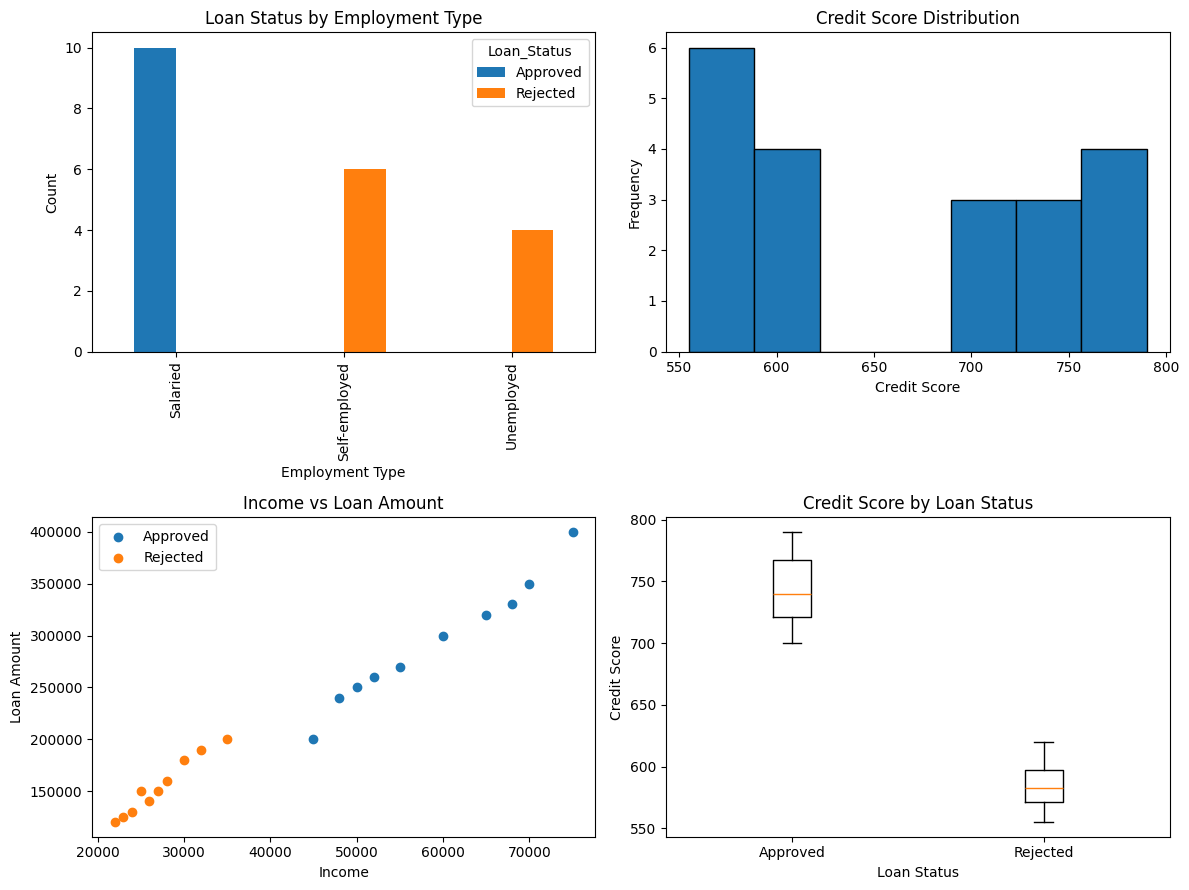

In [16]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
pd.crosstab(bank['Employment_Type'], bank['Loan_Status']).plot(kind='bar', ax=axes[0,0], title='Loan Status by Employment Type')
axes[0,0].set_xlabel('Employment Type'); axes[0,0].set_ylabel('Count')
axes[0,1].hist(bank['Credit_Score'], bins=7, edgecolor='black'); axes[0,1].set_title('Credit Score Distribution'); axes[0,1].set_xlabel('Credit Score'); axes[0,1].set_ylabel('Frequency')
for value, sub in bank.groupby('Loan_Status'): axes[1,0].scatter(sub['Income'], sub['Loan_Amount'], label=value)
axes[1,0].set_title('Income vs Loan Amount'); axes[1,0].set_xlabel('Income'); axes[1,0].set_ylabel('Loan Amount'); axes[1,0].legend()
axes[1,1].boxplot([bank.loc[bank.Loan_Status=='Approved','Credit_Score'], bank.loc[bank.Loan_Status=='Rejected','Credit_Score']], tick_labels=['Approved','Rejected'])
axes[1,1].set_title('Credit Score by Loan Status'); axes[1,1].set_xlabel('Loan Status'); axes[1,1].set_ylabel('Credit Score')
plt.tight_layout(); plt.show()


              Income  Credit_Score  Loan_Amount
Income         1.000         0.984        0.988
Credit_Score   0.984         1.000        0.954
Loan_Amount    0.988         0.954        1.000


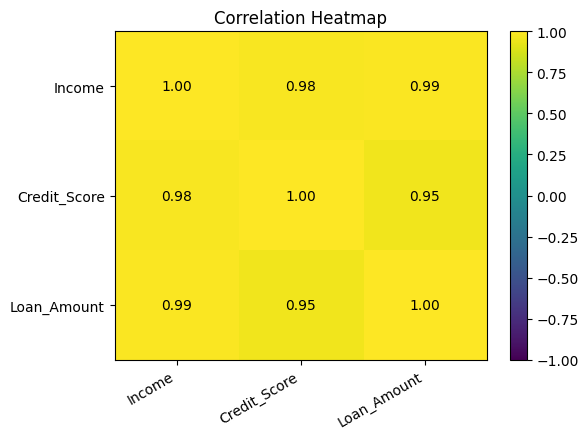

In [17]:
numeric_cols = bank.select_dtypes(include='number').columns
corr = bank[list(numeric_cols)].corr()
print(corr.round(3))
plt.figure(figsize=(6,4.5))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for r in range(len(corr)):
    for c in range(len(corr)):
        plt.text(c, r, f"{corr.iloc[r,c]:.2f}", ha='center', va='center')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Key Findings and Insights

1. Approved applications have substantially higher credit scores than rejected applications.
2. Approved and rejected customers form clearly separated credit-score groups in this sample.
3. Income and loan amount have a very strong positive relationship.
4. All Salaried customers in this dataset are approved, while all Unemployed customers are rejected.
5. No missing values, duplicate rows or IQR outliers were found.

### Conclusion

Credit score, income and employment type show strong associations with approval status in this small dataset. These patterns can support preliminary screening, but real lending decisions require larger and more representative data.

## Agriculture Crop Yield Dataset

**Purpose & Significance:** An agricultural department wants to identify how rainfall, temperature, fertilizer usage and soil type are associated with crop yield.

In [18]:
agri = pd.DataFrame({
'Farm_ID':[f'F{i:02d}' for i in range(1,21)],
'Rainfall_mm':[850,600,900,500,780,650,920,720,550,800,880,620,760,940,580,820,700,960,540,790],
'Temperature':[28,32,27,34,29,31,26,30,33,28,27,32,29,26,33,28,30,25,34,29],
'Fertilizer_kg':[60,45,65,40,55,48,70,52,42,58,62,46,54,72,44,60,50,75,41,56],
'Soil_Type':['Loamy','Sandy','Loamy','Sandy','Clay','Sandy','Loamy','Clay','Sandy','Loamy','Loamy','Sandy','Clay','Loamy','Sandy','Clay','Clay','Loamy','Sandy','Clay'],
'Crop_Yield_kg':[3200,2100,3500,1800,3000,2300,3700,2800,1900,3100,3400,2200,2950,3800,2000,3150,2700,3900,1850,3050]})
eda_profile(agri, 'Agriculture Crop Yield Dataset', ['Rainfall_mm','Temperature','Fertilizer_kg','Crop_Yield_kg'])


Agriculture Crop Yield Dataset
Shape: (20, 6)

Data types:
Farm_ID          object
Rainfall_mm       int64
Temperature       int64
Fertilizer_kg     int64
Soil_Type        object
Crop_Yield_kg     int64
dtype: object

Missing values:
Farm_ID          0
Rainfall_mm      0
Temperature      0
Fertilizer_kg    0
Soil_Type        0
Crop_Yield_kg    0
dtype: int64

Duplicate rows: 0

Descriptive statistics:
                  mean  median     min     max     std
Rainfall_mm     743.00   770.0   500.0   960.0  144.34
Temperature      29.55    29.0    25.0    34.0    2.76
Fertilizer_kg    54.75    54.5    40.0    75.0   10.51
Crop_Yield_kg  2820.00  2975.0  1800.0  3900.0  681.41

IQR outlier counts:
Rainfall_mm : 0
Temperature : 0
Fertilizer_kg : 0
Crop_Yield_kg : 0


In [19]:
print(agri['Soil_Type'].value_counts())
print((agri['Soil_Type'].value_counts(normalize=True)*100).round(2))


Soil_Type
Loamy    7
Sandy    7
Clay     6
Name: count, dtype: int64
Soil_Type
Loamy    35.0
Sandy    35.0
Clay     30.0
Name: proportion, dtype: float64


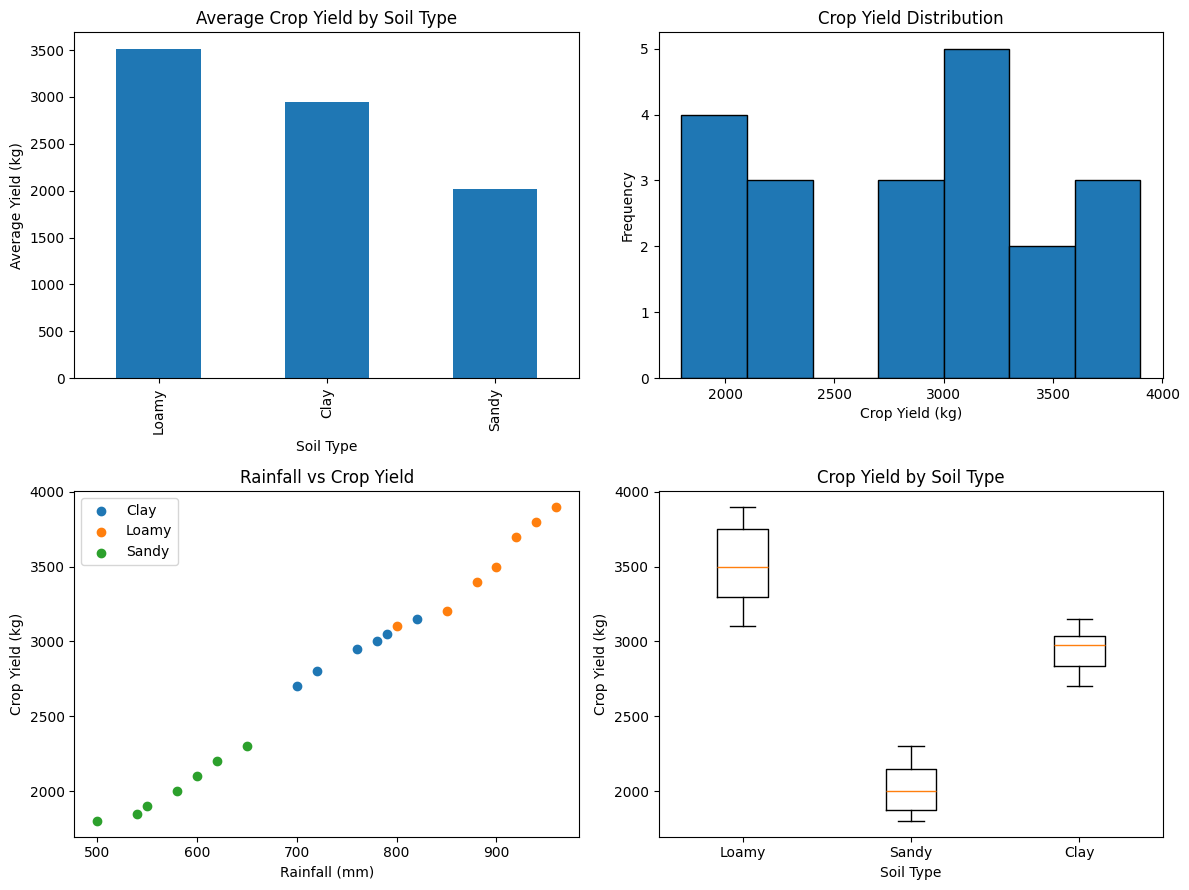

In [20]:
fig, axes = plt.subplots(2,2, figsize=(12,9))
agri.groupby('Soil_Type')['Crop_Yield_kg'].mean().sort_values(ascending=False).plot(kind='bar', ax=axes[0,0], title='Average Crop Yield by Soil Type')
axes[0,0].set_xlabel('Soil Type'); axes[0,0].set_ylabel('Average Yield (kg)')
axes[0,1].hist(agri['Crop_Yield_kg'], bins=7, edgecolor='black'); axes[0,1].set_title('Crop Yield Distribution'); axes[0,1].set_xlabel('Crop Yield (kg)'); axes[0,1].set_ylabel('Frequency')
for value, sub in agri.groupby('Soil_Type'): axes[1,0].scatter(sub['Rainfall_mm'], sub['Crop_Yield_kg'], label=value)
axes[1,0].set_title('Rainfall vs Crop Yield'); axes[1,0].set_xlabel('Rainfall (mm)'); axes[1,0].set_ylabel('Crop Yield (kg)'); axes[1,0].legend()
axes[1,1].boxplot([agri.loc[agri.Soil_Type==c,'Crop_Yield_kg'] for c in ['Loamy','Sandy','Clay']], tick_labels=['Loamy','Sandy','Clay'])
axes[1,1].set_title('Crop Yield by Soil Type'); axes[1,1].set_xlabel('Soil Type'); axes[1,1].set_ylabel('Crop Yield (kg)')
plt.tight_layout(); plt.show()


               Rainfall_mm  Temperature  Fertilizer_kg  Crop_Yield_kg
Rainfall_mm          1.000       -0.993          0.981          0.996
Temperature         -0.993        1.000         -0.980         -0.993
Fertilizer_kg        0.981       -0.980          1.000          0.983
Crop_Yield_kg        0.996       -0.993          0.983          1.000


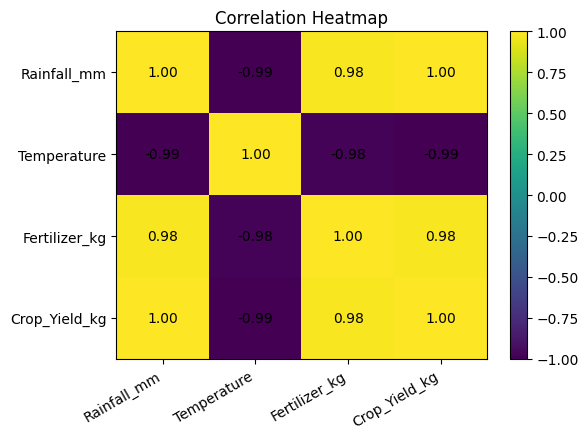

In [21]:
numeric_cols = agri.select_dtypes(include='number').columns
corr = agri[list(numeric_cols)].corr()
print(corr.round(3))
plt.figure(figsize=(6,4.5))
plt.imshow(corr, aspect='auto', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=30, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)
for r in range(len(corr)):
    for c in range(len(corr)):
        plt.text(c, r, f"{corr.iloc[r,c]:.2f}", ha='center', va='center')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


### Key Findings and Insights

1. Rainfall has a very strong positive relationship with crop yield.
2. Temperature has a strong negative relationship with crop yield.
3. Loamy soil has the highest average crop yield, followed by Clay and Sandy soil.
4. Fertilizer usage is positively associated with crop yield in this sample.
5. No missing values, duplicate rows or IQR outliers were found.

### Conclusion

Rainfall and fertilizer are positively associated with crop yield while temperature is negatively associated in this sample. Loamy soil gives the highest average yield, supporting soil-specific crop and irrigation planning.